In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [6]:
df = pd.read_csv("../data/netflix_titles.csv")

In [7]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Red Notice,Rawson Marshall Thurber,Dwayne Johnson; Ryan Reynolds; Gal Gadot,United States,"November 12, 2021",2021,PG-13,118 min,Action & Adventure,An FBI profiler pursues the world's most wante...
1,s2,TV Show,Squid Game,Hwang Dong-hyuk,Lee Jung-jae; Park Hae-soo,South Korea,"September 17, 2021",2021,TV-MA,1 Season,"Thrillers, International TV Shows",Hundreds of players compete in deadly childhoo...
2,s3,Movie,Extraction,Sam Hargrave,Chris Hemsworth,United States,"April 24, 2020",2020,R,116 min,Action & Adventure,A mercenary rescues a kidnapped boy.
3,s4,Movie,The Irishman,Martin Scorsese,Robert De Niro; Al Pacino,United States,"November 27, 2019",2019,R,209 min,"Crime, Drama",A mob hitman recalls his past.
4,s5,TV Show,Money Heist,Alex Pina,Úrsula Corberó; Álvaro Morte,Spain,"May 2, 2017",2017,TV-MA,5 Seasons,Crime TV Shows,A criminal mastermind plans the biggest heist.


In [8]:
df.shape

(20, 12)

In [9]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       20 non-null     object
 1   type          20 non-null     object
 2   title         20 non-null     object
 3   director      20 non-null     object
 4   cast          20 non-null     object
 5   country       20 non-null     object
 6   date_added    20 non-null     object
 7   release_year  20 non-null     int64 
 8   rating        20 non-null     object
 9   duration      20 non-null     object
 10  listed_in     20 non-null     object
 11  description   20 non-null     object
dtypes: int64(1), object(11)
memory usage: 2.0+ KB


In [11]:
df.describe()

,release_year
count,20.000000
mean,2018.950000
std,4.045465
min,2009.000000
25%,2016.750000
50%,2020.500000
75%,2022.000000
max,2023.000000


In [12]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

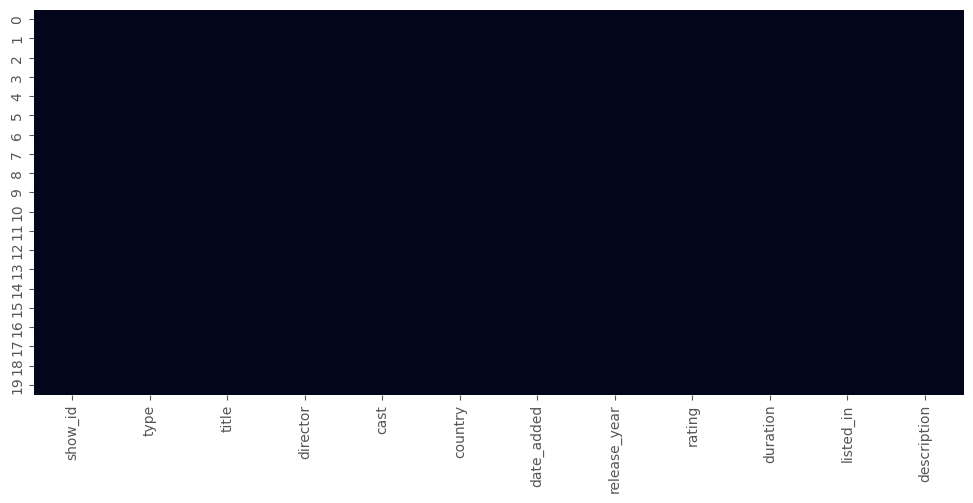

In [13]:
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
df["director"] = df["director"].fillna("Unknown")

df["country"] = df["country"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Unknown")

In [17]:
df["type"].value_counts()

type
Movie      13
TV Show     7
Name: count, dtype: int64

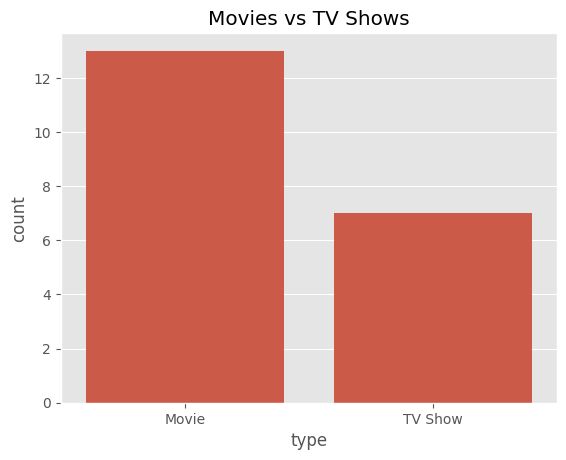

In [18]:
sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows")

plt.show()

In [19]:
df["rating"].value_counts()

rating
TV-MA    8
PG-13    5
TV-14    4
R        2
PG       1
Name: count, dtype: int64

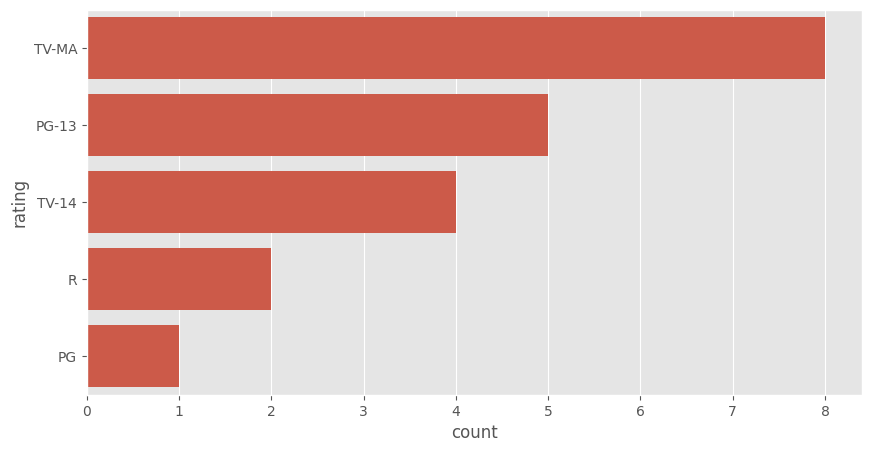

In [20]:
plt.figure(figsize=(10,5))

sns.countplot(y="rating", data=df,
              order=df["rating"].value_counts().index)

plt.show()

In [21]:
country = df["country"].value_counts().head(10)

country

country
United States     8
India             6
South Korea       2
Spain             2
Germany           1
United Kingdom    1
Name: count, dtype: int64

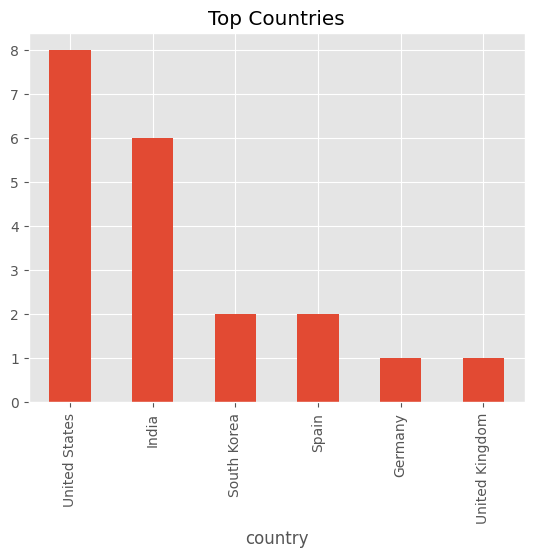

In [22]:
country.plot(kind="bar")

plt.title("Top Countries")

plt.show()

In [23]:
release = df["release_year"].value_counts().sort_index()

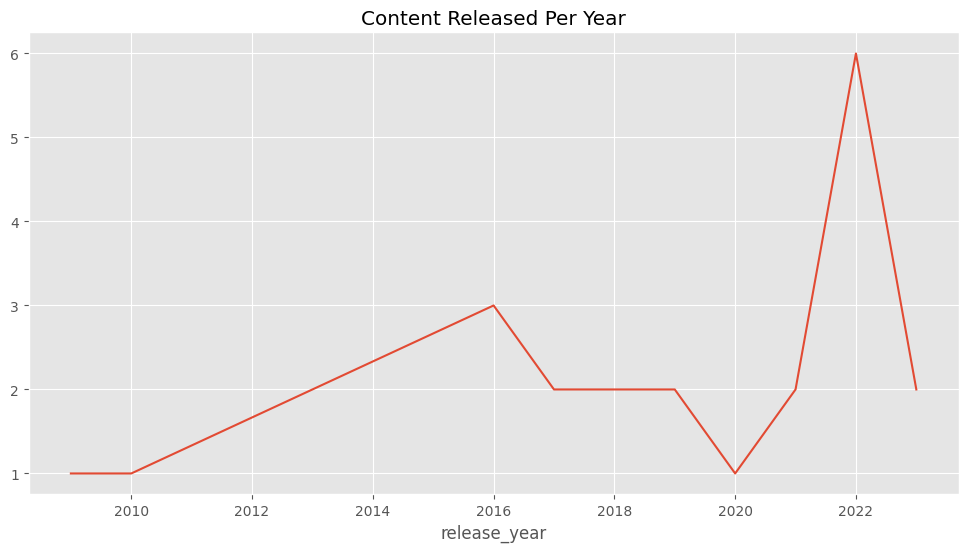

In [24]:
plt.figure(figsize=(12,6))

release.plot()

plt.title("Content Released Per Year")

plt.show()

In [25]:
genre = df["listed_in"].str.split(", ").explode()

genre.value_counts().head(10)

listed_in
Action & Adventure        7
Drama                     5
Sci-Fi & Fantasy          3
International TV Shows    2
Comedy                    2
Horror                    2
Thrillers                 1
Crime                     1
Crime TV Shows            1
Mystery                   1
Name: count, dtype: int64

<Axes: xlabel='listed_in'>

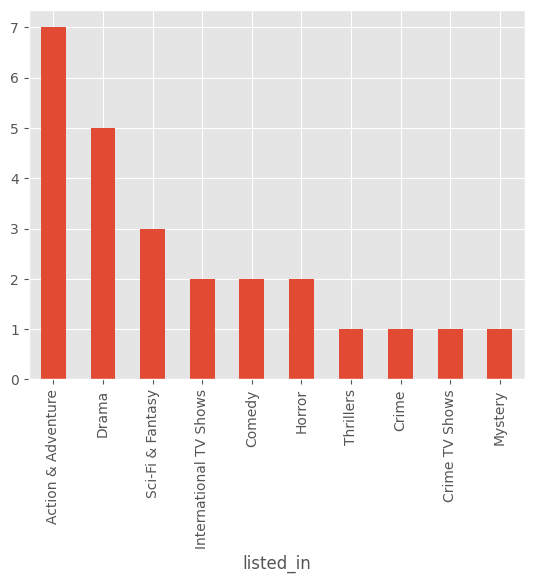

In [27]:
genre.value_counts().head(10).plot(kind="bar")

In [28]:
director = df["director"].value_counts().head(10)

director

director
Rawson Marshall Thurber    1
Hwang Dong-hyuk            1
Rishab Shetty              1
David Fincher              1
Peter Morgan               1
Galder Gaztelu-Urrutia     1
Nitesh Tiwari              1
Baran bo Odar              1
Lokesh Kanagaraj           1
Atlee                      1
Name: count, dtype: int64

<Axes: ylabel='director'>

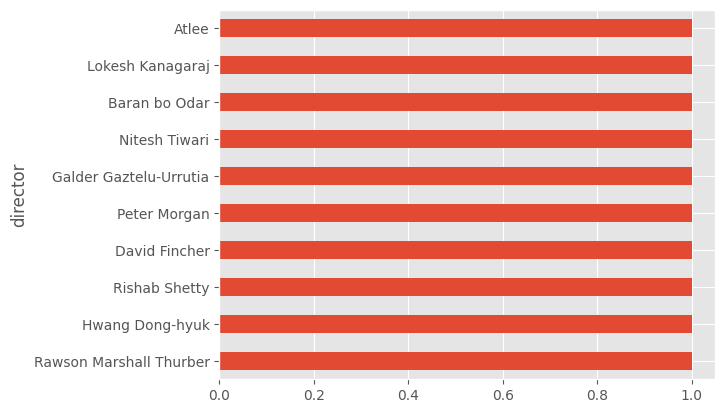

In [29]:
director.plot(kind="barh")

In [30]:
movies = df[df["type"]=="Movie"]

movies["minutes"] = movies["duration"].str.replace(" min","").astype(int)

/var/folders/zd/1hm7v8sj4bg171t8pl3h8wyc0000gn/T/ipykernel_78065/3099247469.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies["minutes"] = movies["duration"].str.replace(" min","").astype(int)


In [31]:
movies["minutes"].describe()

count     13.000000
mean     145.153846
std       33.867010
min       95.000000
25%      118.000000
50%      148.000000
75%      169.000000
max      209.000000
Name: minutes, dtype: float64

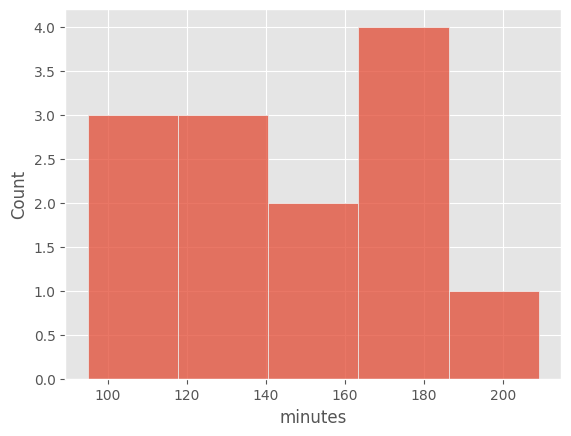

In [32]:
sns.histplot(movies["minutes"])

plt.show()

In [33]:
tv = df[df["type"]=="TV Show"]

tv["duration"].value_counts().head(10)

duration
1 Season     3
5 Seasons    1
4 Seasons    1
3 Seasons    1
6 Seasons    1
Name: count, dtype: int64

In [35]:
movie_year = movies.groupby("release_year").size()

<Axes: xlabel='release_year'>

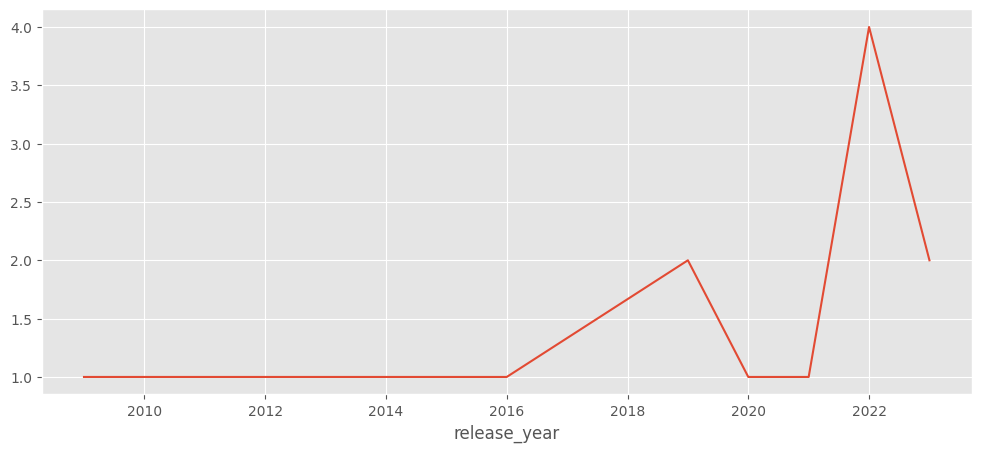

In [36]:
movie_year.plot(figsize=(12,5))

In [37]:
numeric = movies[["release_year","minutes"]]

numeric.corr()

,release_year,minutes
release_year,1.000000,-0.015325
minutes,-0.015325,1.000000


<Axes: >

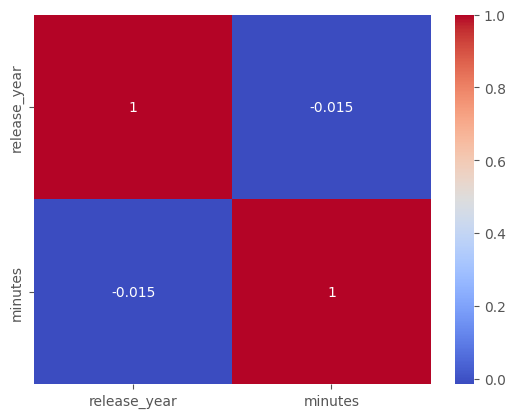

In [38]:
sns.heatmap(numeric.corr(),
            annot=True,
            cmap="coolwarm")

In [39]:
df["country"].value_counts().head(10)

country
United States     8
India             6
South Korea       2
Spain             2
Germany           1
United Kingdom    1
Name: count, dtype: int64

In [40]:
df["release_year"].value_counts().idxmax()

np.int64(2022)

In [41]:
df["rating"].mode()

0    TV-MA
Name: rating, dtype: object

In [42]:
movies["minutes"].mean()

np.float64(145.15384615384616)

In [43]:
genre.value_counts().head(1)


listed_in
Action & Adventure    7
Name: count, dtype: int64

In [45]:
df["director"].value_counts().head()

director
Rawson Marshall Thurber    1
Hwang Dong-hyuk            1
Rishab Shetty              1
David Fincher              1
Peter Morgan               1
Name: count, dtype: int64

In [46]:
df["type"].value_counts(normalize=True)*100

type
Movie      65.0
TV Show    35.0
Name: proportion, dtype: float64

<Axes: xlabel='type', ylabel='release_year'>

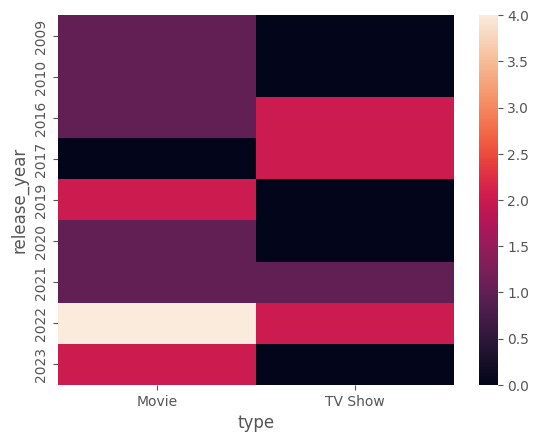

In [47]:
pivot = pd.pivot_table(
    df,
    index="release_year",
    columns="type",
    aggfunc="size",
    fill_value=0
)

sns.heatmap(pivot)

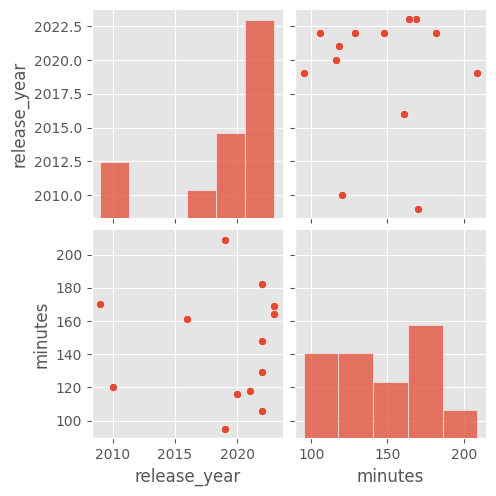

In [48]:
sns.pairplot(numeric)

<Axes: xlabel='minutes'>

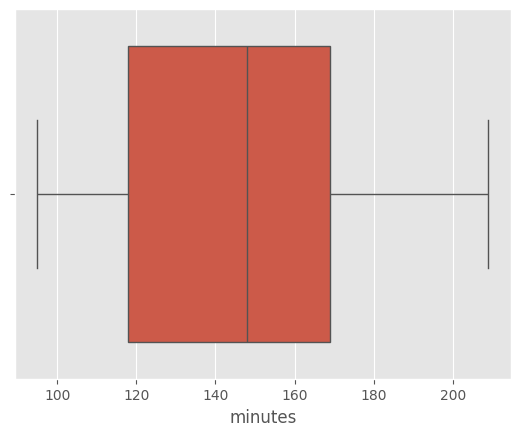

In [49]:
sns.boxplot(x=movies["minutes"])

<Axes: xlabel='minutes'>

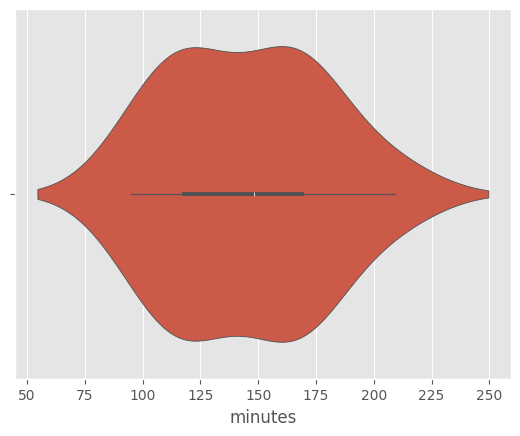

In [50]:
sns.violinplot(x=movies["minutes"])

<Axes: xlabel='minutes', ylabel='Density'>

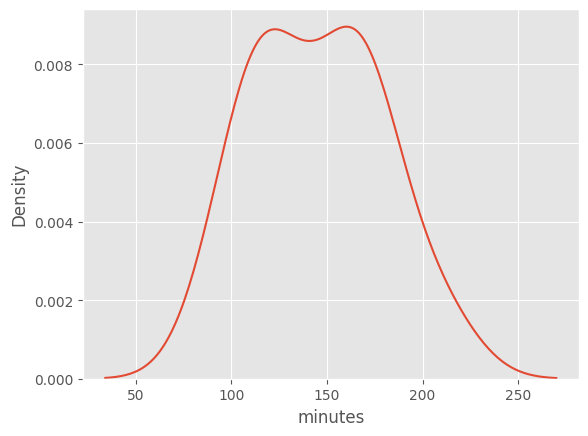

In [51]:
sns.kdeplot(movies["minutes"])

Netflix contains more Movies than TV Shows.
The United States contributes the highest number of titles.
Content releases increased significantly after 2015.
Drama and International Movies are among the most common genres.
TV-MA is one of the most frequent content ratings.
Most movies are around 90–120 minutes long.